# Comprensión y análisis exploratorio de datos (EDA)

**Proyecto:** modelo de riesgo crediticio  
**Versión:** 1.0.1  
**Rama:** `developer`

## Objetivo

Comprender el esquema, calidad, distribución y relaciones del dataset antes de construir un modelo. El análisis comprende:

1. Exploración inicial y caracterización de variables.
2. Unificación de nulos y corrección exploratoria de tipos.
3. Análisis univariable.
4. Análisis bivariable respecto de `Pago_atiempo`.
5. Análisis multivariable.
6. Reglas de validación, transformaciones candidatas y atributos derivados.

> Las correcciones se aplican únicamente a una copia en memoria llamada `df`. El CSV original permanece intacto. Las decisiones definitivas se implementarán mediante un pipeline en el siguiente avance.

## 1. Librerías y configuración

In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

## 2. Carga reproducible

In [19]:
rutas_posibles = [Path("Base_de_datos.csv"), Path("../Base_de_datos.csv")]
ruta_datos = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_datos is None:
    raise FileNotFoundError("No se encontró Base_de_datos.csv.")

df_crudo = pd.read_csv(ruta_datos, low_memory=False)
df = df_crudo.copy(deep=True)

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
display(df.head())

Dimensiones: 10,763 filas x 23 columnas


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


## 3. Comprensión detallada del esquema

La clasificación analítica evita tratar códigos como cantidades. Por ejemplo, `tipo_credito` contiene números, pero funciona como una categoría nominal; no tiene sentido calcular su promedio.

In [20]:
diccionario_datos = pd.DataFrame([
    ["tipo_credito", "Predictora", "Categórica", "Nominal politómica", "Código del tipo de crédito"],
    ["fecha_prestamo", "Predictora", "Temporal", "Fecha y hora", "Momento de otorgamiento"],
    ["capital_prestado", "Predictora", "Numérica", "Continua", "Capital otorgado"],
    ["plazo_meses", "Predictora", "Numérica", "Discreta", "Plazo pactado en meses"],
    ["edad_cliente", "Predictora", "Numérica", "Discreta", "Edad informada del cliente"],
    ["tipo_laboral", "Predictora", "Categórica", "Nominal dicotómica", "Situación laboral"],
    ["salario_cliente", "Predictora", "Numérica", "Continua", "Salario informado"],
    ["total_otros_prestamos", "Predictora", "Numérica", "Continua", "Total de otros préstamos"],
    ["cuota_pactada", "Predictora", "Numérica", "Continua", "Valor de la cuota"],
    ["puntaje", "Predictora a auditar", "Numérica", "Continua", "Puntaje interno; revisar posible fuga"],
    ["puntaje_datacredito", "Predictora", "Numérica", "Continua", "Puntaje externo de crédito"],
    ["cant_creditosvigentes", "Predictora", "Numérica", "Discreta", "Cantidad de créditos vigentes"],
    ["huella_consulta", "Predictora", "Numérica", "Discreta", "Cantidad de consultas"],
    ["saldo_mora", "Predictora", "Numérica", "Continua", "Saldo en mora"],
    ["saldo_total", "Predictora", "Numérica", "Continua", "Saldo total"],
    ["saldo_principal", "Predictora", "Numérica", "Continua", "Saldo principal"],
    ["saldo_mora_codeudor", "Predictora", "Numérica", "Continua", "Mora del codeudor"],
    ["creditos_sectorFinanciero", "Predictora", "Numérica", "Discreta", "Créditos del sector financiero"],
    ["creditos_sectorCooperativo", "Predictora", "Numérica", "Discreta", "Créditos del sector cooperativo"],
    ["creditos_sectorReal", "Predictora", "Numérica", "Discreta", "Créditos del sector real"],
    ["promedio_ingresos_datacredito", "Predictora", "Numérica", "Continua", "Ingreso promedio externo"],
    ["tendencia_ingresos", "Predictora", "Categórica", "Ordinal politómica", "Decreciente < Estable < Creciente"],
    ["Pago_atiempo", "Objetivo", "Categórica", "Dicotómica", "0 = no paga a tiempo; 1 = paga a tiempo"],
], columns=["variable", "rol", "familia", "subtipo", "interpretacion"])

diccionario_datos

,variable,rol,familia,subtipo,interpretacion
0,tipo_credito,Predictora,Categórica,Nominal politómica,Código del tipo de crédito
1,fecha_prestamo,Predictora,Temporal,Fecha y hora,Momento de otorgamiento
2,capital_prestado,Predictora,Numérica,Continua,Capital otorgado
3,plazo_meses,Predictora,Numérica,Discreta,Plazo pactado en meses
4,edad_cliente,Predictora,Numérica,Discreta,Edad informada del cliente
5,tipo_laboral,Predictora,Categórica,Nominal dicotómica,Situación laboral
6,salario_cliente,Predictora,Numérica,Continua,Salario informado
7,total_otros_prestamos,Predictora,Numérica,Continua,Total de otros préstamos
8,cuota_pactada,Predictora,Numérica,Continua,Valor de la cuota
9,puntaje,Predictora a auditar,Numérica,Continua,Puntaje interno; revisar posible fuga


In [21]:
resumen_inicial = pd.DataFrame({
    "tipo_leido": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(dropna=True),
})

print(f"Duplicados exactos: {df.duplicated().sum():,}")
resumen_inicial.sort_values("nulos_%", ascending=False)

Duplicados exactos: 0


,tipo_leido,nulos,nulos_%,unicos
tendencia_ingresos,str,2932,27.24,46
promedio_ingresos_datacredito,float64,2930,27.22,5309
saldo_mora_codeudor,float64,590,5.48,4
saldo_principal,float64,405,3.76,8647
saldo_mora,float64,156,1.45,55
saldo_total,float64,156,1.45,8858
puntaje_datacredito,float64,6,0.06,315
salario_cliente,int64,0,0.00,1385
tipo_laboral,str,0,0.00,2
edad_cliente,int64,0,0.00,54


## 4. Unificación de valores nulos

Primero se normalizan marcadores habituales (`""`, espacios, `NA`, `N/A`, `null`, etc.). Luego se validan las categorías conocidas. Los números encontrados en `tendencia_ingresos` no representan una categoría válida y se convierten en `NaN` dentro de la copia exploratoria.

In [22]:
marcadores_nulos = ["", " ", "NA", "N/A", "NAN", "nan", "null", "NULL", "None", "-", "Sin dato"]
columnas_texto = ["tipo_laboral", "tendencia_ingresos"]

for columna in columnas_texto:
    df[columna] = df[columna].astype("string").str.strip()
    df[columna] = df[columna].replace(marcadores_nulos, pd.NA)

tendencias_permitidas = ["Decreciente", "Estable", "Creciente"]
mascara_tendencia_invalida = (
    df["tendencia_ingresos"].notna()
    & ~df["tendencia_ingresos"].isin(tendencias_permitidas)
)
cantidad_tendencias_invalidas = int(mascara_tendencia_invalida.sum())
ejemplos_tendencia_invalida = df.loc[mascara_tendencia_invalida, "tendencia_ingresos"].head(10).tolist()

df.loc[mascara_tendencia_invalida, "tendencia_ingresos"] = pd.NA

print(f"Valores no válidos convertidos a nulo en tendencia_ingresos: {cantidad_tendencias_invalidas}")
print(f"Ejemplos encontrados: {ejemplos_tendencia_invalida}")

Valores no válidos convertidos a nulo en tendencia_ingresos: 58
Ejemplos encontrados: ['8315', '0', '158042', '3978', '9147', '8315', '168750', '-28589', '8315', '1000000']


**Interpretación:** unificar nulos no equivale a imputarlos. En esta etapa solo logramos una representación consistente. La estrategia de imputación debe aprenderse exclusivamente con los datos de entrenamiento para evitar fuga de información.

## 5. Conversión y uniformidad de tipos

In [23]:
columnas_numericas_continuas = [
    "capital_prestado", "salario_cliente", "total_otros_prestamos",
    "cuota_pactada", "puntaje", "puntaje_datacredito", "saldo_mora",
    "saldo_total", "saldo_principal", "saldo_mora_codeudor",
    "promedio_ingresos_datacredito",
]

columnas_numericas_discretas = [
    "plazo_meses", "edad_cliente", "cant_creditosvigentes", "huella_consulta",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal",
]

for columna in columnas_numericas_continuas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce").astype("Float64")

for columna in columnas_numericas_discretas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce").round().astype("Int64")

df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")
df["tipo_credito"] = pd.to_numeric(df["tipo_credito"], errors="coerce").astype("Int64").astype("category")
df["tipo_laboral"] = df["tipo_laboral"].astype("category")
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype(
    pd.CategoricalDtype(categories=tendencias_permitidas, ordered=True)
)
df["Pago_atiempo"] = pd.to_numeric(df["Pago_atiempo"], errors="coerce").astype("Int64")

tipos_ajustados = pd.DataFrame({
    "tipo_final": df.dtypes.astype(str),
    "nulos_finales": df.isna().sum(),
    "nulos_finales_%": (df.isna().mean() * 100).round(2),
})
tipos_ajustados

,tipo_final,nulos_finales,nulos_finales_%
tipo_credito,category,0,0.00
fecha_prestamo,datetime64[us],0,0.00
capital_prestado,Float64,0,0.00
plazo_meses,Int64,0,0.00
edad_cliente,Int64,0,0.00
tipo_laboral,category,0,0.00
salario_cliente,Float64,0,0.00
total_otros_prestamos,Float64,0,0.00
cuota_pactada,Float64,0,0.00
puntaje,Float64,0,0.00


## 6. Variables irrelevantes

No se encontraron identificadores únicos, columnas constantes ni campos puramente administrativos que deban eliminarse automáticamente. Se conservan las 23 variables durante el EDA:

- `fecha_prestamo` permite estudiar cambios temporales y derivar mes/trimestre.
- `tipo_credito` es un código categórico, no una magnitud.
- `puntaje` se conserva temporalmente para auditar posible fuga de información.

**Regla:** una variable solo se eliminará si existe una justificación de negocio, fuga de información, redundancia comprobada o falta de disponibilidad al momento de predecir.

In [24]:
revision_relevancia = pd.DataFrame({
    "variable": df.columns,
    "accion_eda": "Conservar",
    "motivo": "Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente",
})
revision_relevancia.loc[revision_relevancia["variable"] == "puntaje", "accion_eda"] = "Conservar y auditar"
revision_relevancia.loc[revision_relevancia["variable"] == "puntaje", "motivo"] = "Correlación muy alta con el objetivo; posible data leakage"
revision_relevancia

,variable,accion_eda,motivo
0,tipo_credito,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
1,fecha_prestamo,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
2,capital_prestado,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
3,plazo_meses,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
4,edad_cliente,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
5,tipo_laboral,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
6,salario_cliente,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
7,total_otros_prestamos,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
8,cuota_pactada,Conservar,Potencial valor predictivo o utilidad para validación; decisión definitiva pendiente
9,puntaje,Conservar y auditar,Correlación muy alta con el objetivo; posible data leakage


## 7. Reglas de calidad y validación propuestas

In [25]:
columnas_monetarias = [
    "capital_prestado", "salario_cliente", "total_otros_prestamos", "cuota_pactada",
    "saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor",
    "promedio_ingresos_datacredito",
]
columnas_conteo = [
    "plazo_meses", "cant_creditosvigentes", "huella_consulta",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal",
]

resultados_reglas = [
    ["Pago_atiempo", "Debe pertenecer a {0, 1}", int((~df["Pago_atiempo"].isin([0, 1]) & df["Pago_atiempo"].notna()).sum()), "Rechazar o revisar"],
    ["edad_cliente", "Debe estar entre 18 y 100 años", int(((df["edad_cliente"] < 18) | (df["edad_cliente"] > 100)).sum()), "Validar con la fuente; no borrar automáticamente"],
    ["salario_cliente", "Debe ser mayor que 0 para calcular ratios", int((df["salario_cliente"] <= 0).sum()), "Tratar como faltante para ratios y validar"],
    ["puntaje_datacredito", "Debe estar entre 0 y 999", int(((df["puntaje_datacredito"] < 0) | (df["puntaje_datacredito"] > 999)).sum()), "Validar con la fuente"],
    ["tendencia_ingresos", "Debe pertenecer a las categorías permitidas", cantidad_tendencias_invalidas, "Unificar inválidos como nulos y validar"],
    ["columnas_monetarias", "No deben ser negativas", int(sum((df[c] < 0).sum() for c in columnas_monetarias)), "Rechazar o revisar"],
    ["columnas_de_conteo", "Deben ser enteros no negativos", int(sum((df[c] < 0).sum() for c in columnas_conteo)), "Rechazar o revisar"],
    ["fecha_prestamo", "Debe ser una fecha válida", int(df["fecha_prestamo"].isna().sum()), "Revisar formato/origen"],
]

reglas_validacion = pd.DataFrame(
    resultados_reglas,
    columns=["campo", "regla_propuesta", "incumplimientos_observados", "accion_sugerida"],
)
reglas_validacion

,campo,regla_propuesta,incumplimientos_observados,accion_sugerida
0,Pago_atiempo,"Debe pertenecer a {0, 1}",0,Rechazar o revisar
1,edad_cliente,Debe estar entre 18 y 100 años,150,Validar con la fuente; no borrar automáticamente
2,salario_cliente,Debe ser mayor que 0 para calcular ratios,24,Tratar como faltante para ratios y validar
3,puntaje_datacredito,Debe estar entre 0 y 999,1,Validar con la fuente
4,tendencia_ingresos,Debe pertenecer a las categorías permitidas,58,Unificar inválidos como nulos y validar
5,columnas_monetarias,No deben ser negativas,0,Rechazar o revisar
6,columnas_de_conteo,Deben ser enteros no negativos,0,Rechazar o revisar
7,fecha_prestamo,Debe ser una fecha válida,0,Revisar formato/origen


Las reglas anteriores son propuestas basadas en el esquema y en criterios plausibles. Los límites deben confirmarse con el responsable del negocio antes de implementarlos en producción.

# Análisis univariable

El análisis univariable estudia una variable por vez. Para las numéricas se revisan tendencia central, dispersión, forma y valores atípicos. Para las categóricas se revisan frecuencias y proporciones.

## 8. Estadística descriptiva de variables numéricas

In [26]:
variables_numericas = columnas_numericas_continuas + columnas_numericas_discretas

def moda_primera(serie):
    modas = serie.mode(dropna=True)
    return modas.iloc[0] if not modas.empty else np.nan

estadisticas_numericas = pd.DataFrame(index=variables_numericas)
estadisticas_numericas["count"] = df[variables_numericas].count()
estadisticas_numericas["nulos_%"] = (df[variables_numericas].isna().mean() * 100).round(2)
estadisticas_numericas["media"] = df[variables_numericas].mean()
estadisticas_numericas["mediana"] = df[variables_numericas].median()
estadisticas_numericas["moda"] = df[variables_numericas].apply(moda_primera)
estadisticas_numericas["min"] = df[variables_numericas].min()
estadisticas_numericas["q1"] = df[variables_numericas].quantile(0.25)
estadisticas_numericas["q3"] = df[variables_numericas].quantile(0.75)
estadisticas_numericas["max"] = df[variables_numericas].max()
estadisticas_numericas["rango"] = estadisticas_numericas["max"] - estadisticas_numericas["min"]
estadisticas_numericas["iqr"] = estadisticas_numericas["q3"] - estadisticas_numericas["q1"]
estadisticas_numericas["varianza"] = df[variables_numericas].var()
estadisticas_numericas["desvio_estandar"] = df[variables_numericas].std()
estadisticas_numericas["skewness"] = df[variables_numericas].skew()
estadisticas_numericas["kurtosis"] = df[variables_numericas].kurt()

estadisticas_numericas["forma_segun_asimetria"] = estadisticas_numericas["skewness"].apply(
    lambda valor: "Aproximadamente simétrica" if abs(valor) < 0.5
    else "Asimetría moderada" if abs(valor) < 1
    else "Asimetría fuerte"
)

estadisticas_numericas

,count,nulos_%,media,mediana,moda,min,q1,q3,max,rango,iqr,varianza,desvio_estandar,skewness,kurtosis,forma_segun_asimetria
capital_prestado,10763,0.00,"2,434,315.00","1,921,920.00","1,200,000.00","360,000.00","1,224,831.00","3,084,840.00","41,444,152.80","41,084,152.80","1,860,009.00","3,646,735,466,988.66","1,909,642.76",3.72,35.32,Asimetría fuerte
salario_cliente,10763,0.00,"17,216,431.46","3,000,000.00","3,000,000.00",0.00,"2,000,000.00","4,875,808.00","22,000,000,000.00","22,000,000,000.00","2,875,808.00","126,363,696,758,146,032.00","355,476,717.60",43.78,"2,211.23",Asimetría fuerte
total_otros_prestamos,10763,0.00,"6,238,869.65","1,000,000.00","2,000,000.00",0.00,"500,000.00","2,000,000.00","6,787,675,263.00","6,787,675,263.00","1,500,000.00","14,022,897,787,155,474.00","118,418,316.94",38.46,"1,719.28",Asimetría fuerte
cuota_pactada,10763,0.00,"243,617.41","182,863.00","205,990.00","23,944.00","121,041.50","287,833.50","3,816,752.00","3,792,808.00","166,792.00","44,307,595,469.58","210,493.69",3.79,26.65,Asimetría fuerte
puntaje,10763,0.00,91.17,95.23,95.23,-38.01,95.23,95.23,95.23,133.24,0.00,271.11,16.47,-4.87,24.08,Asimetría fuerte
puntaje_datacredito,10757,0.06,780.79,791.00,0.00,-7.00,757.00,825.00,999.00,"1,006.00",68.00,"10,999.40",104.88,-5.64,39.44,Asimetría fuerte
saldo_mora,10607,1.45,7.75,0.00,0.00,0.00,0.00,0.00,"12,534.00","12,534.00",0.00,"51,055.72",225.96,40.57,"1,845.71",Asimetría fuerte
saldo_total,10607,1.45,"45,937.41","16,178.00",0.00,0.00,"2,898.00","52,982.00","5,116,066.00","5,116,066.00","50,084.00","11,293,268,248.81","106,269.79",20.20,789.17,Asimetría fuerte
saldo_principal,10358,3.76,"40,346.17","14,442.50",0.00,0.00,"2,690.00","47,632.25","1,562,285.00","1,562,285.00","44,942.25","5,075,485,304.48","71,242.44",5.05,51.06,Asimetría fuerte
saldo_mora_codeudor,10173,5.48,0.26,0.00,0.00,0.00,0.00,0.00,"2,145.00","2,145.00",0.00,474.06,21.77,94.97,"9,279.82",Asimetría fuerte


**Cómo interpretar:**

- Media y mediana muy diferentes sugieren asimetría o valores extremos.
- El IQR mide el ancho del 50% central y es más robusto que el rango.
- `skewness` positiva indica una cola más larga hacia valores altos; negativa, hacia valores bajos.
- `kurtosis` elevada señala colas pesadas o presencia de observaciones extremas.
- La forma indicada por asimetría es orientativa; no demuestra por sí sola que una distribución sea gaussiana.

## 9. Histogramas y boxplots

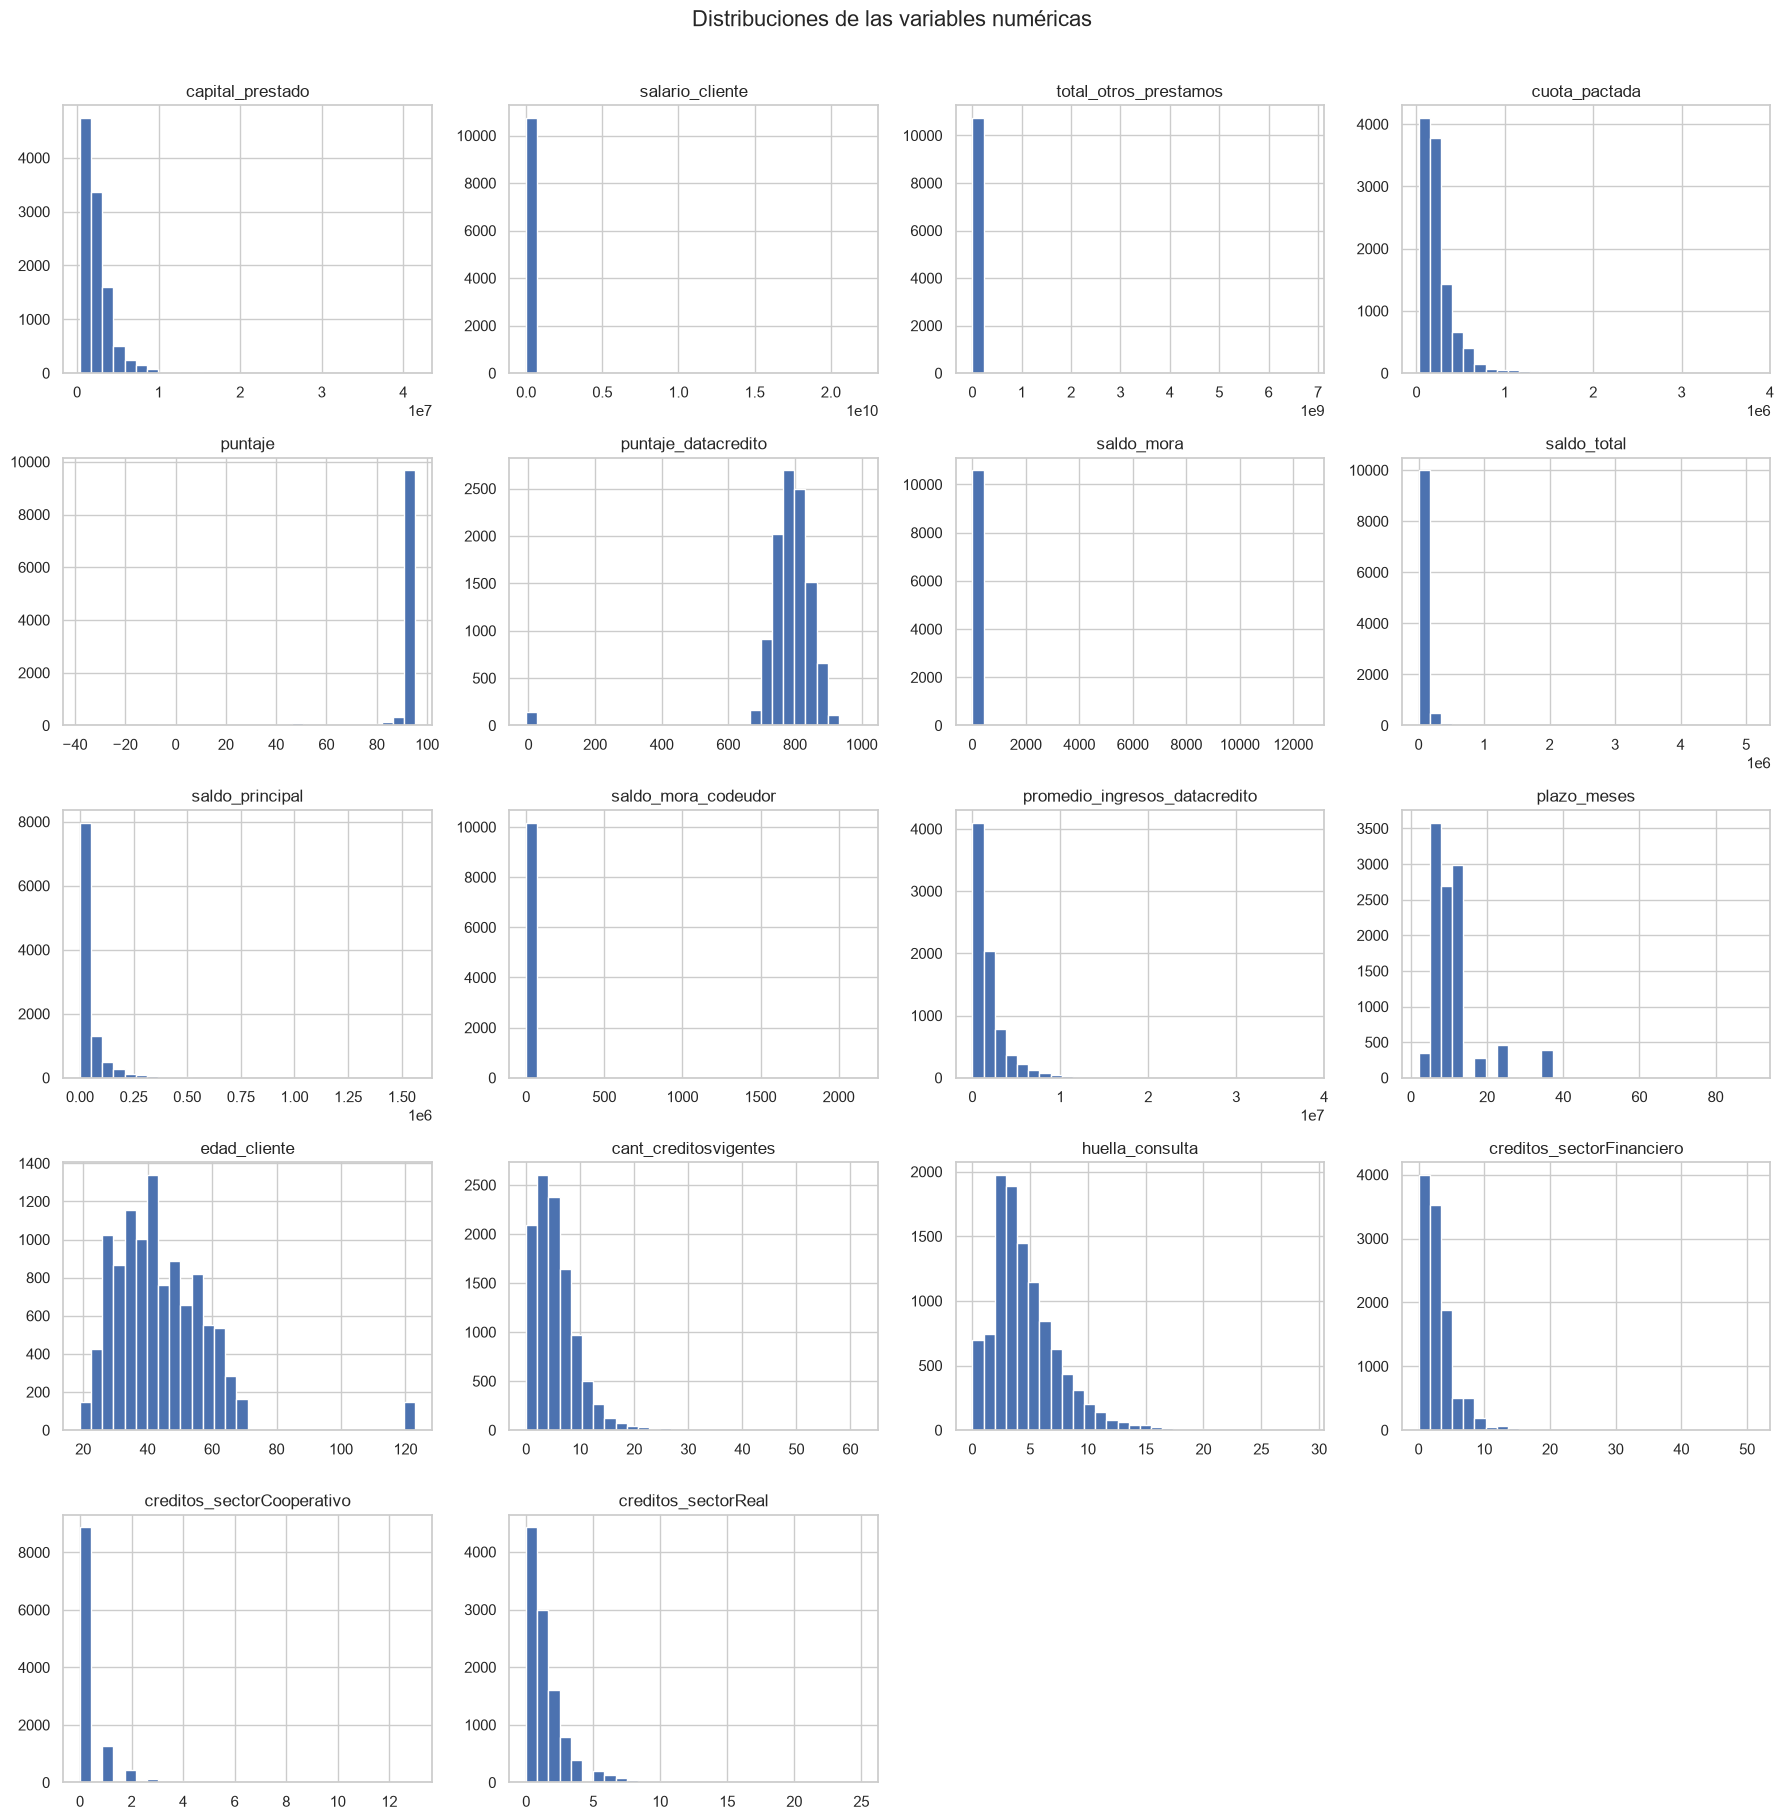

In [27]:
df[variables_numericas].astype(float).hist(
    figsize=(18, 18), bins=30, color="#4C72B0", edgecolor="white", layout=(5, 4)
)
plt.suptitle("Distribuciones de las variables numéricas", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

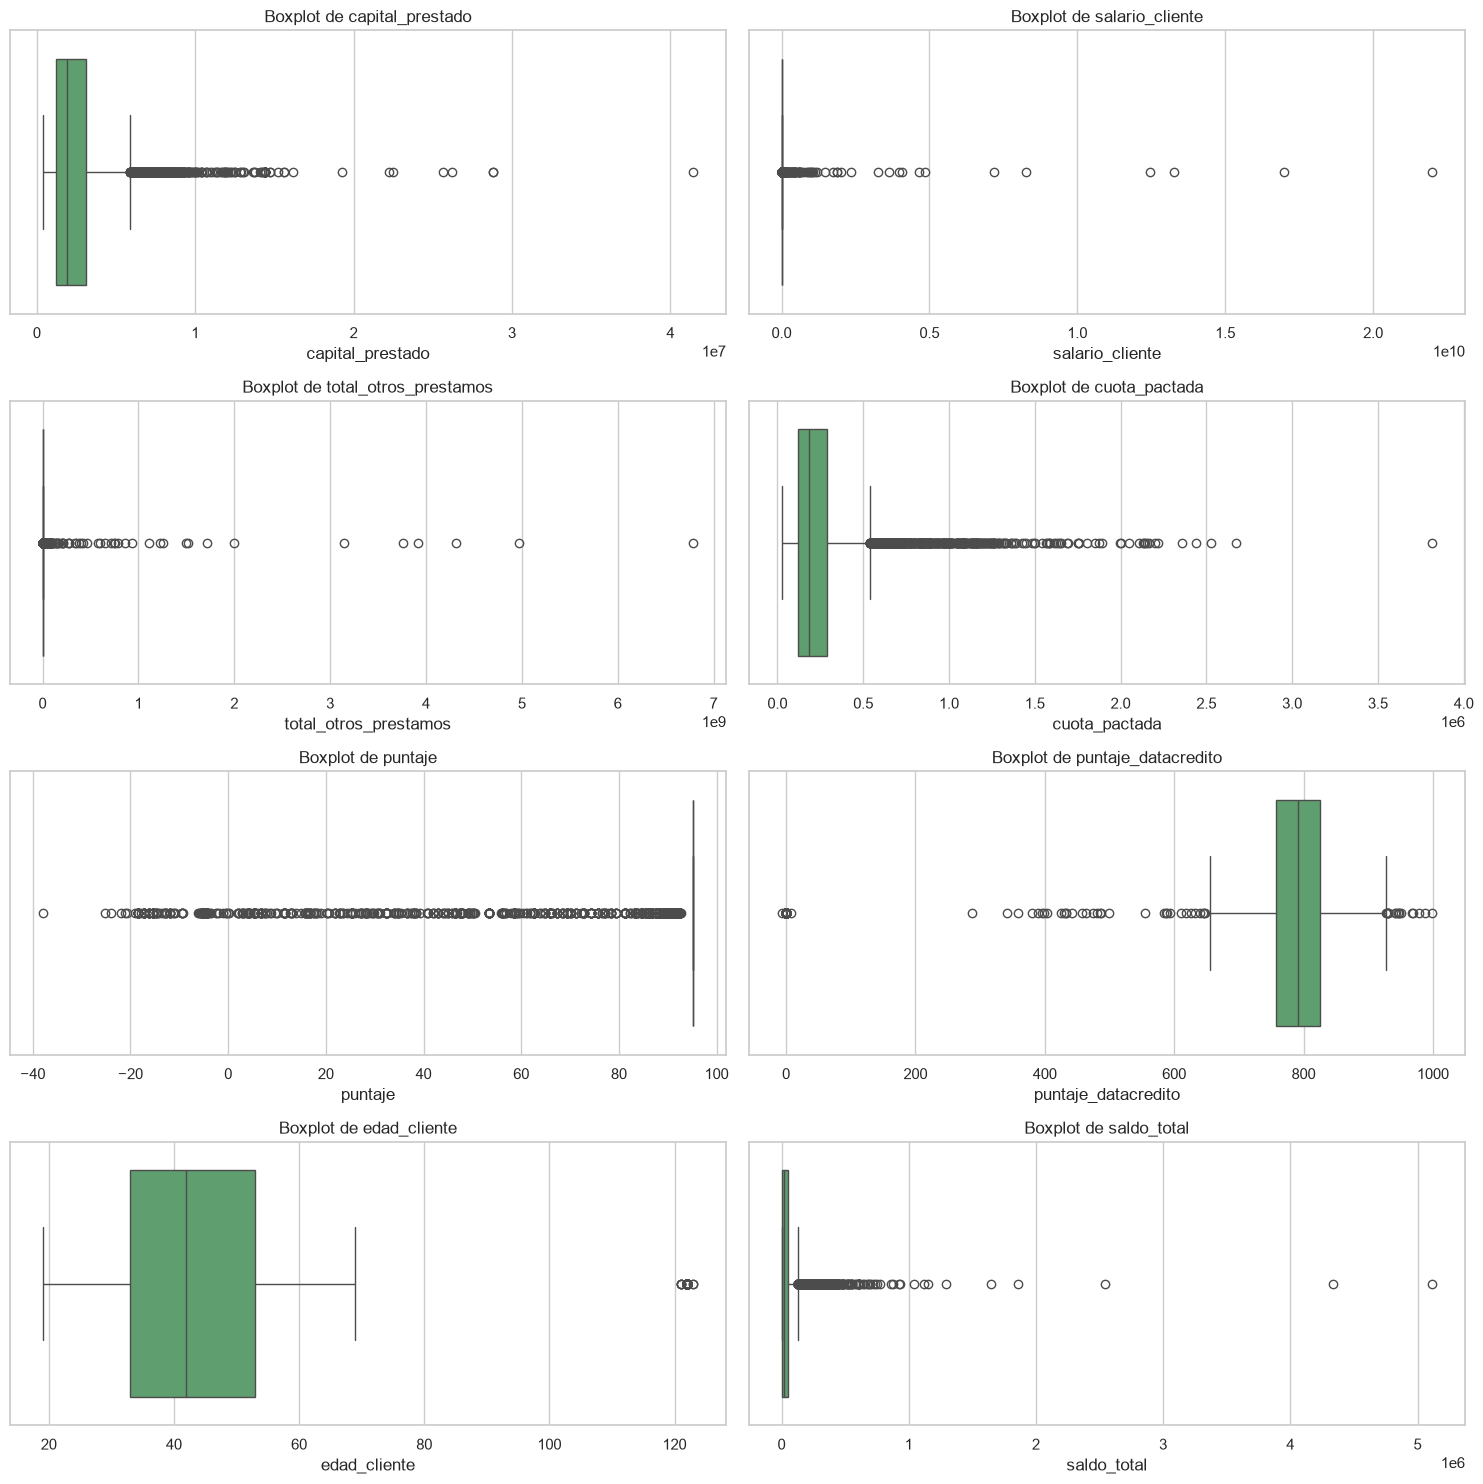

In [28]:
variables_boxplot = [
    "capital_prestado", "salario_cliente", "total_otros_prestamos", "cuota_pactada",
    "puntaje", "puntaje_datacredito", "edad_cliente", "saldo_total",
]

fig, axes = plt.subplots(4, 2, figsize=(15, 15))
for variable, eje in zip(variables_boxplot, axes.flat):
    sns.boxplot(x=df[variable].astype(float), ax=eje, color="#55A868")
    eje.set_title(f"Boxplot de {variable}")
plt.tight_layout()
plt.show()

**Hallazgo:** las variables monetarias presentan colas derechas extensas. Los boxplots sirven para detectar observaciones alejadas, pero no justifican eliminarlas: podrían representar clientes reales de alto valor. Para modelado se evaluarán transformaciones `log1p`, escalado robusto o winsorización respaldada por negocio.

## 10. Variables categóricas y objetivo

In [29]:
variables_categoricas = ["tipo_credito", "tipo_laboral", "tendencia_ingresos", "Pago_atiempo"]

for variable in variables_categoricas:
    tabla = pd.DataFrame({
        "cantidad": df[variable].value_counts(dropna=False),
        "porcentaje": (df[variable].value_counts(normalize=True, dropna=False) * 100).round(2),
    })
    print(f"Distribución de {variable}")
    display(tabla)

Distribución de tipo_credito


,cantidad,porcentaje
tipo_credito,,
4,7747,71.98
9,2876,26.72
10,116,1.08
6,21,0.20
7,2,0.02
68,1,0.01


Distribución de tipo_laboral


,cantidad,porcentaje
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25


Distribución de tendencia_ingresos


,cantidad,porcentaje
tendencia_ingresos,,
Creciente,5294,49.19
NaN,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04


Distribución de Pago_atiempo


,cantidad,porcentaje
Pago_atiempo,,
1,10252,95.25
0,511,4.75


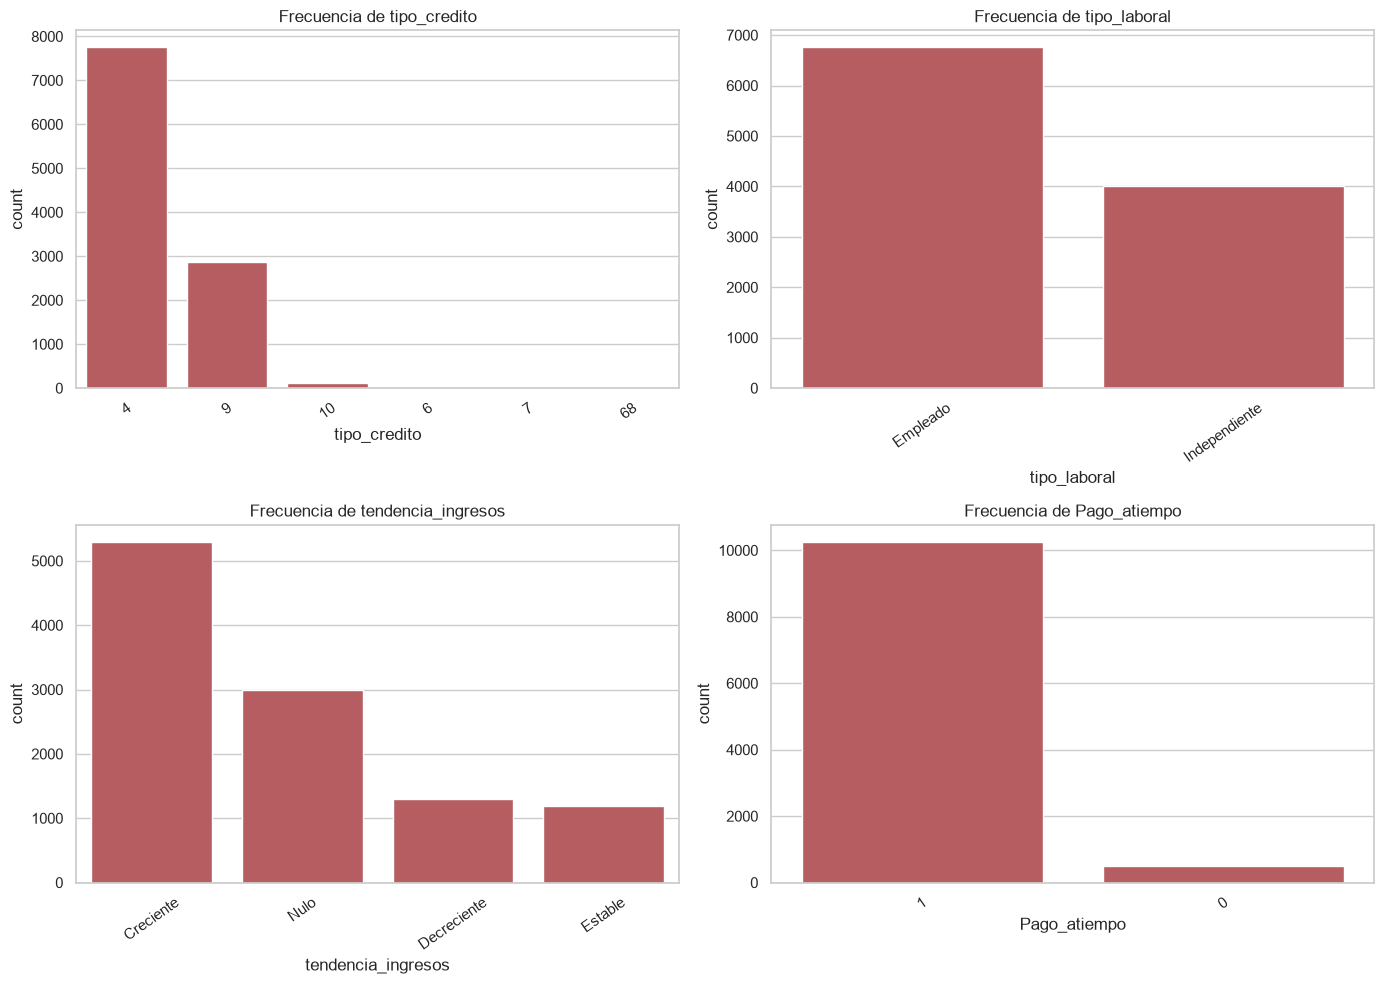

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variable, eje in zip(variables_categoricas, axes.flat):
    datos_grafico = df.copy()
    datos_grafico[variable] = datos_grafico[variable].astype("string").fillna("Nulo")
    orden = datos_grafico[variable].value_counts().index
    sns.countplot(data=datos_grafico, x=variable, order=orden, ax=eje, color="#C44E52")
    eje.set_title(f"Frecuencia de {variable}")
    eje.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Hallazgo crítico:** `Pago_atiempo` está fuertemente desbalanceada: aproximadamente 95,25% corresponde a la clase 1 y 4,75% a la clase 0. Un modelo que siempre prediga 1 tendría una accuracy alta sin ser útil para detectar incumplimientos. En modelado deberán utilizarse división estratificada y métricas como precision, recall, F1 y ROC-AUC.

# Análisis bivariable

## 11. Variables categóricas respecto del objetivo

In [31]:
def tasa_objetivo_por(categoria):
    tabla = (
        df.groupby(categoria, observed=False, dropna=False)["Pago_atiempo"]
          .agg(cantidad="size", pagos_a_tiempo="sum", tasa_pago_a_tiempo="mean")
          .reset_index()
    )
    tabla["tasa_pago_a_tiempo_%"] = (tabla["tasa_pago_a_tiempo"] * 100).round(2)
    return tabla.sort_values("tasa_pago_a_tiempo")

for variable in ["tipo_laboral", "tendencia_ingresos", "tipo_credito"]:
    print(f"Tasa de pago a tiempo según {variable}")
    display(tasa_objetivo_por(variable))

Tasa de pago a tiempo según tipo_laboral


,tipo_laboral,cantidad,pagos_a_tiempo,tasa_pago_a_tiempo,tasa_pago_a_tiempo_%
1,Independiente,4009,3788,0.94,94.49
0,Empleado,6754,6464,0.96,95.71


Tasa de pago a tiempo según tendencia_ingresos


,tendencia_ingresos,cantidad,pagos_a_tiempo,tasa_pago_a_tiempo,tasa_pago_a_tiempo_%
0,Decreciente,1291,1210,0.94,93.73
3,NaN,2990,2822,0.94,94.38
1,Estable,1188,1133,0.95,95.37
2,Creciente,5294,5087,0.96,96.09


Tasa de pago a tiempo según tipo_credito


,tipo_credito,cantidad,pagos_a_tiempo,tasa_pago_a_tiempo,tasa_pago_a_tiempo_%
1,6,21,12,0.57,57.14
3,9,2876,2740,0.95,95.27
0,4,7747,7384,0.95,95.31
4,10,116,113,0.97,97.41
2,7,2,2,1.00,100.00
5,68,1,1,1.00,100.00


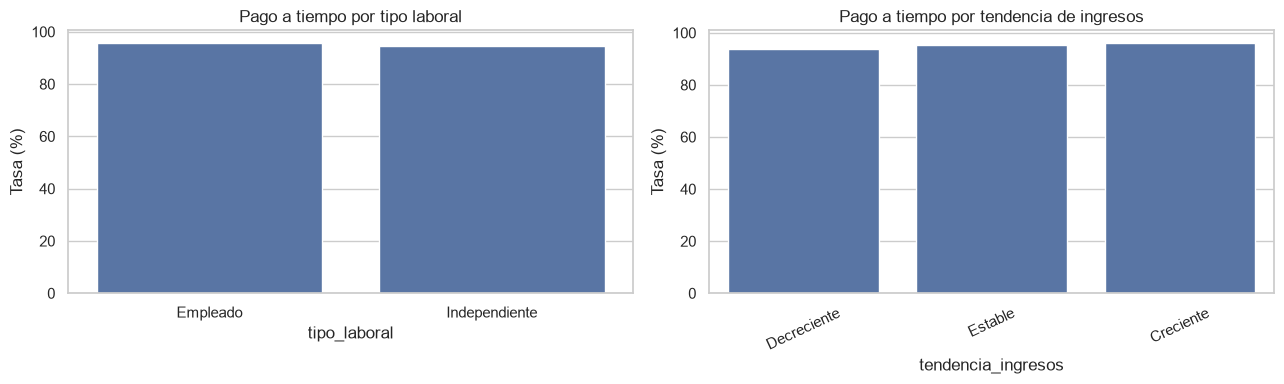

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=tasa_objetivo_por("tipo_laboral"), x="tipo_laboral", y="tasa_pago_a_tiempo_%", ax=axes[0])
axes[0].set_title("Pago a tiempo por tipo laboral")
axes[0].set_ylabel("Tasa (%)")

sns.barplot(data=tasa_objetivo_por("tendencia_ingresos"), x="tendencia_ingresos", y="tasa_pago_a_tiempo_%", ax=axes[1])
axes[1].set_title("Pago a tiempo por tendencia de ingresos")
axes[1].set_ylabel("Tasa (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

**Interpretación:** las tasas permiten comparar grupos, pero deben leerse junto con `cantidad`. Una categoría con muy pocos casos puede mostrar una tasa extrema por azar y no ser estable fuera de la muestra.

## 12. Variables numéricas respecto del objetivo

In [33]:
resumen_por_objetivo = df.groupby("Pago_atiempo")[variables_numericas].agg(["count", "mean", "median", "std"])
resumen_por_objetivo.T

Pago_atiempo                                      0              1
capital_prestado              count             511          10252
                              mean     2,781,774.11   2,416,996.27
                              median   2,268,000.00   1,908,446.40
                              std      1,942,337.70   1,906,438.41
salario_cliente               count             511          10252
                              mean    23,555,143.33  16,900,485.13
                              median   3,000,000.00   3,000,000.00
                              std    274,787,635.68 359,032,091.87
total_otros_prestamos         count             511          10252
                              mean    11,564,401.93   5,973,424.18
                              median     900,000.00   1,000,000.00
                              std    178,148,935.52 114,636,297.61
cuota_pactada                 count             511          10252
                              mean       254,755.69     243,062.23
                              median     199,002.00     182,576.00
                              std        201,712.00     210,915.90
puntaje                       count             511          10252
                              mean            23.09          94.56
                              median          25.42          95.23
                              std             26.07           2.87
puntaje_datacredito           count             510          10247
                              mean           748.88         782.38
                              median         768.00         792.00
                              std            130.91         103.16
saldo_mora                    count             500          10107
                              mean            82.37           4.05
                              median           0.00           0.00
                              std            722.56         165.87
saldo_total                   count             500          10107
                              mean        39,074.92      46,276.90
                              median      14,518.50      16,308.00
                              std         63,386.03     107,940.63
saldo_principal               count             482           9876
                              mean        36,646.43      40,526.73
                              median      13,110.00      14,492.50
                              std         60,082.81      71,740.39
saldo_mora_codeudor           count             471           9702
                              mean             0.00           0.27
                              median           0.00           0.00
                              std              0.00          22.30
promedio_ingresos_datacredito count             343           7490
                              mean     1,605,742.05   2,023,447.77
                              median   1,052,529.00   1,211,296.00
                              std      1,668,892.06   2,161,702.28
plazo_meses                   count             511          10252
                              mean            12.45          10.48
                              median          10.00          10.00
                              std              9.27           6.46
edad_cliente                  count             511          10252
                              mean            41.77          44.06
                              median          38.00          42.00
                              std             17.06          14.95
cant_creditosvigentes         count             511          10252
                              mean             5.57           5.73
                              median           5.00           5.00
                              std              4.14           3.97
huella_consulta               count             511          10252
                              mean             5.24           4.18
                              median           

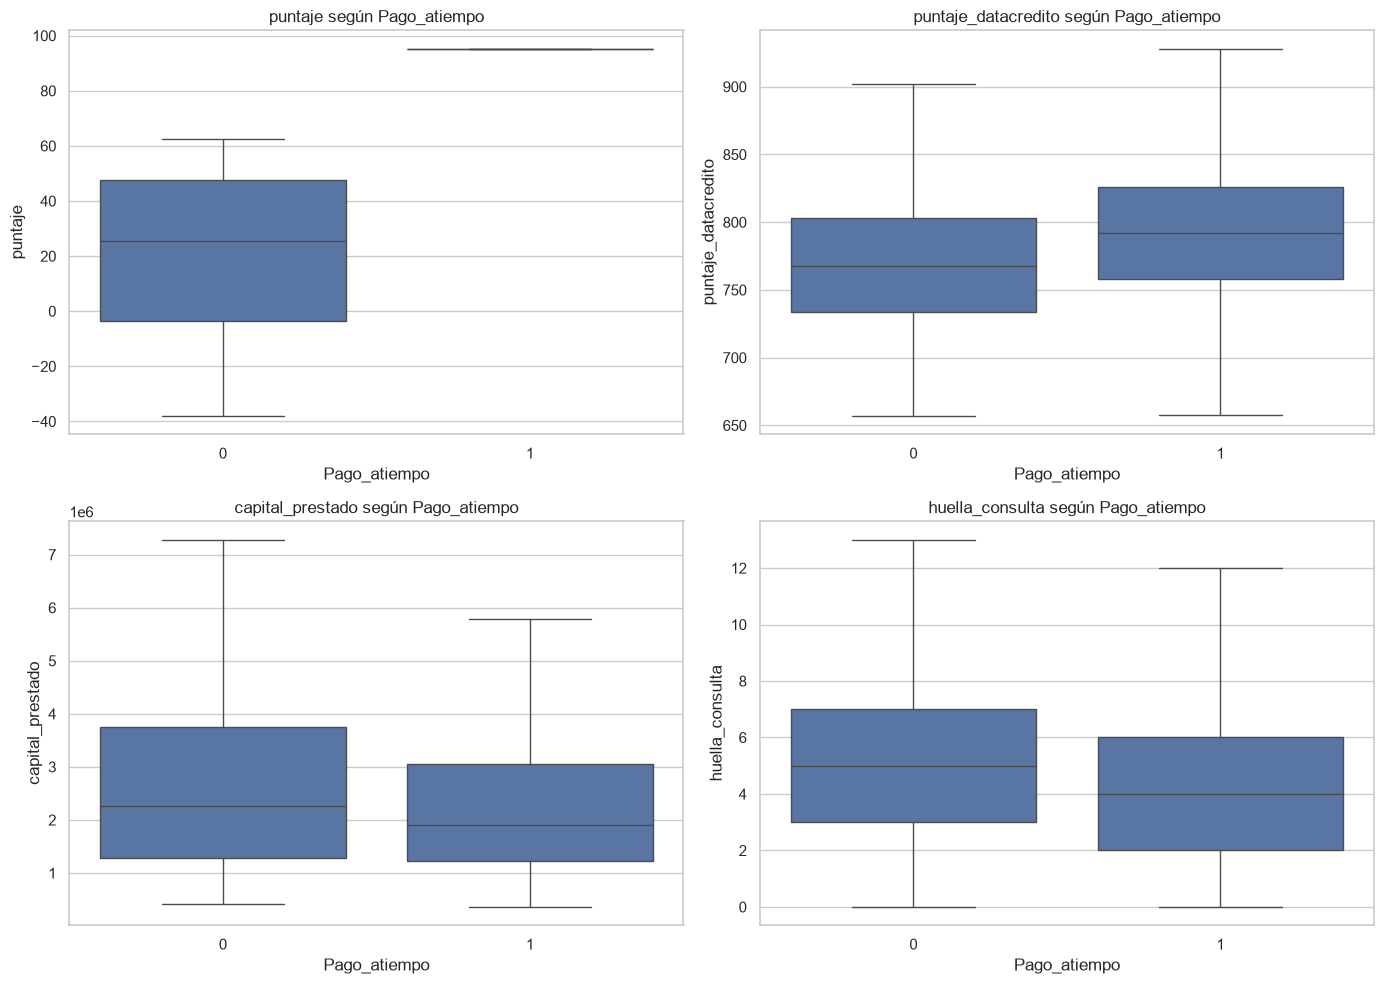

In [34]:
variables_comparacion = ["puntaje", "puntaje_datacredito", "capital_prestado", "huella_consulta"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variable, eje in zip(variables_comparacion, axes.flat):
    sns.boxplot(data=df, x="Pago_atiempo", y=variable, ax=eje, showfliers=False)
    eje.set_title(f"{variable} según Pago_atiempo")
plt.tight_layout()
plt.show()

In [35]:
correlacion_objetivo = (
    df[variables_numericas + ["Pago_atiempo"]]
    .astype(float)
    .corr()["Pago_atiempo"]
    .drop("Pago_atiempo")
    .sort_values(key=abs, ascending=False)
    .rename("correlacion_con_Pago_atiempo")
    .to_frame()
)
correlacion_objetivo

,correlacion_con_Pago_atiempo
puntaje,0.92
huella_consulta,-0.07
saldo_mora,-0.07
puntaje_datacredito,0.07
plazo_meses,-0.06
capital_prestado,-0.04
promedio_ingresos_datacredito,0.04
edad_cliente,0.03
creditos_sectorReal,-0.02
creditos_sectorFinanciero,0.02


**Hallazgo crítico:** `puntaje` presenta una correlación cercana a 0,92 con `Pago_atiempo`, muy superior al resto. Esto puede indicar que el puntaje ya incorpora información directa o posterior sobre el pago. Antes de modelar debe confirmarse cómo y cuándo se calcula. Si no está disponible al momento de otorgar un nuevo crédito, incluirlo produciría `data leakage` y métricas artificialmente altas.

# Análisis multivariable

## 13. Matriz de correlación

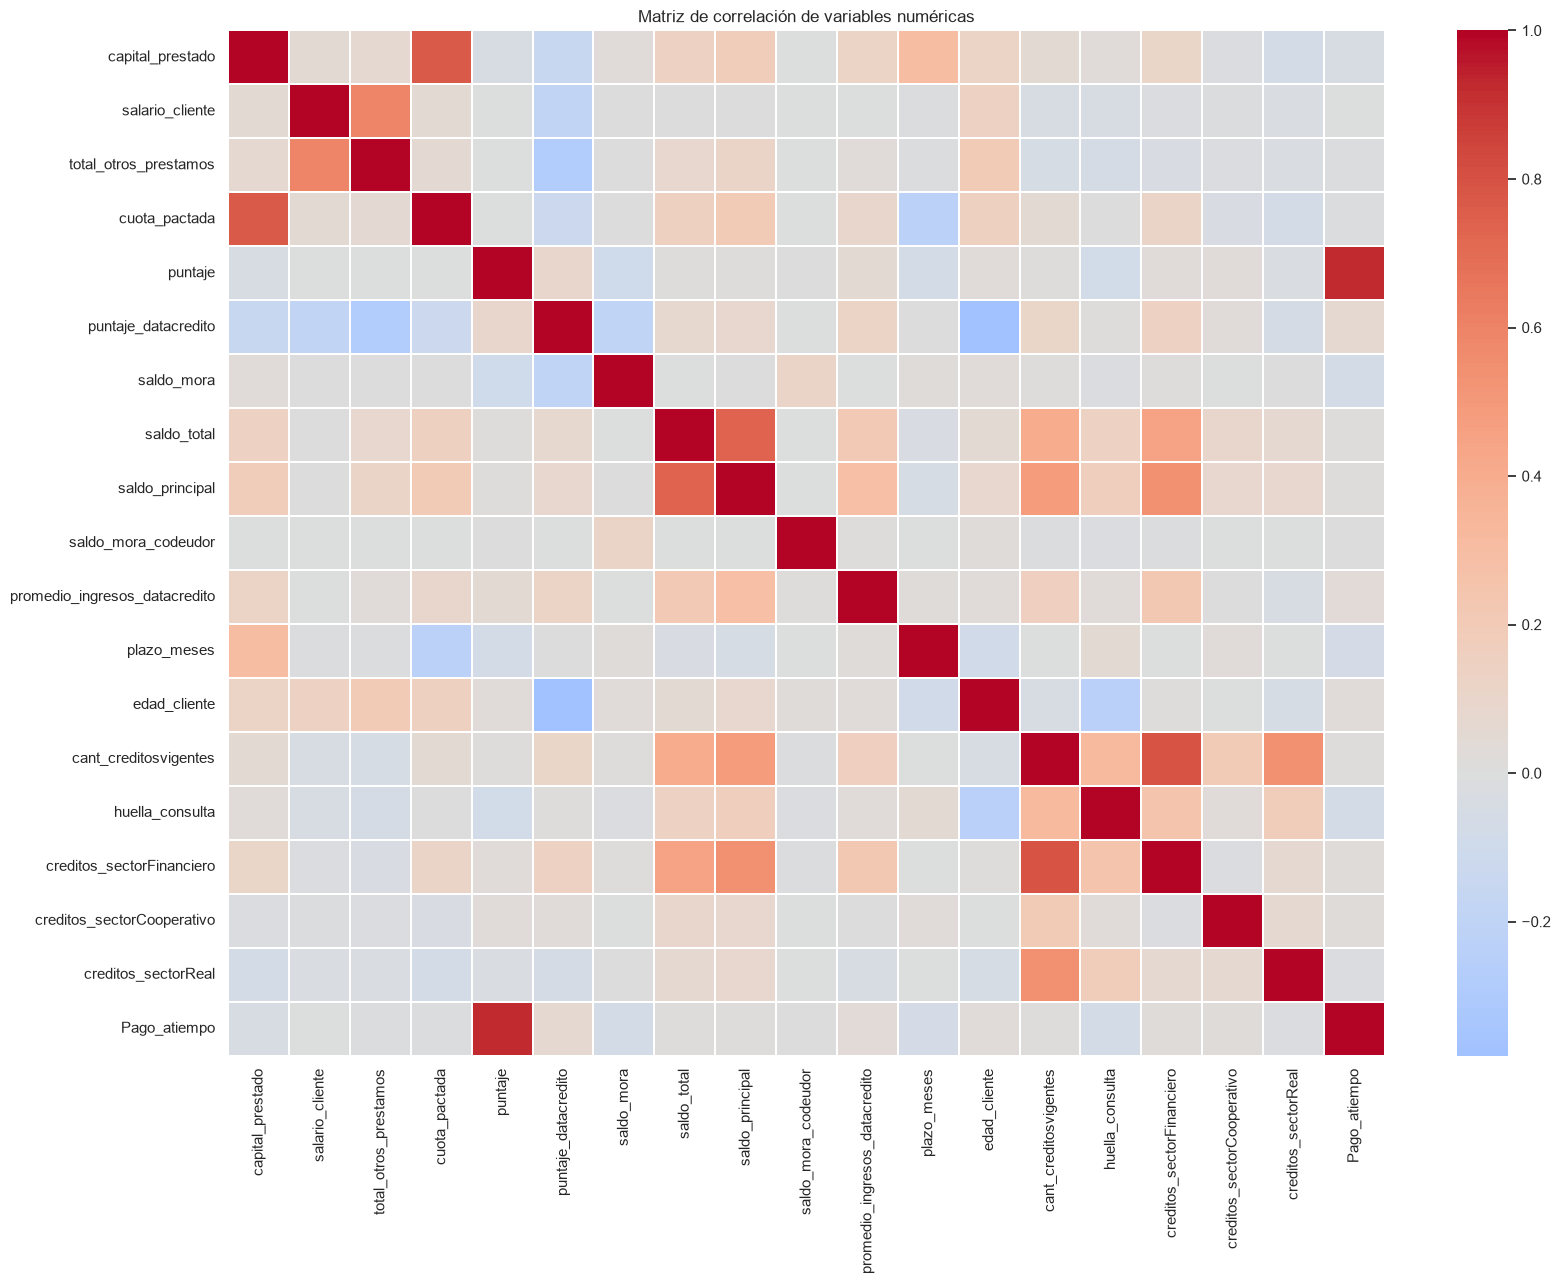

In [36]:
matriz_correlacion = df[variables_numericas + ["Pago_atiempo"]].astype(float).corr()

plt.figure(figsize=(17, 13))
sns.heatmap(matriz_correlacion, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

In [37]:
pares_fuertes = (
    matriz_correlacion.where(np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool))
    .stack()
    .rename("correlacion")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares_fuertes["correlacion_absoluta"] = pares_fuertes["correlacion"].abs()
pares_fuertes.sort_values("correlacion_absoluta", ascending=False).head(15)

,variable_1,variable_2,correlacion,correlacion_absoluta
94,puntaje,Pago_atiempo,0.92,0.92
262,cant_creditosvigentes,creditos_sectorFinanciero,0.79,0.79
3,capital_prestado,cuota_pactada,0.76,0.76
141,saldo_total,saldo_principal,0.73,0.73
21,salario_cliente,total_otros_prestamos,0.60,0.60
264,cant_creditosvigentes,creditos_sectorReal,0.54,0.54
167,saldo_principal,creditos_sectorFinanciero,0.54,0.54
165,saldo_principal,cant_creditosvigentes,0.49,0.49
148,saldo_total,creditos_sectorFinanciero,0.45,0.45
146,saldo_total,cant_creditosvigentes,0.40,0.40


**Interpretación:** correlaciones muy altas entre predictoras pueden señalar redundancia o multicolinealidad. No siempre perjudican a modelos basados en árboles, pero sí afectan la interpretación y algunos modelos lineales.

## 14. Pairplot y dispersión con `hue`

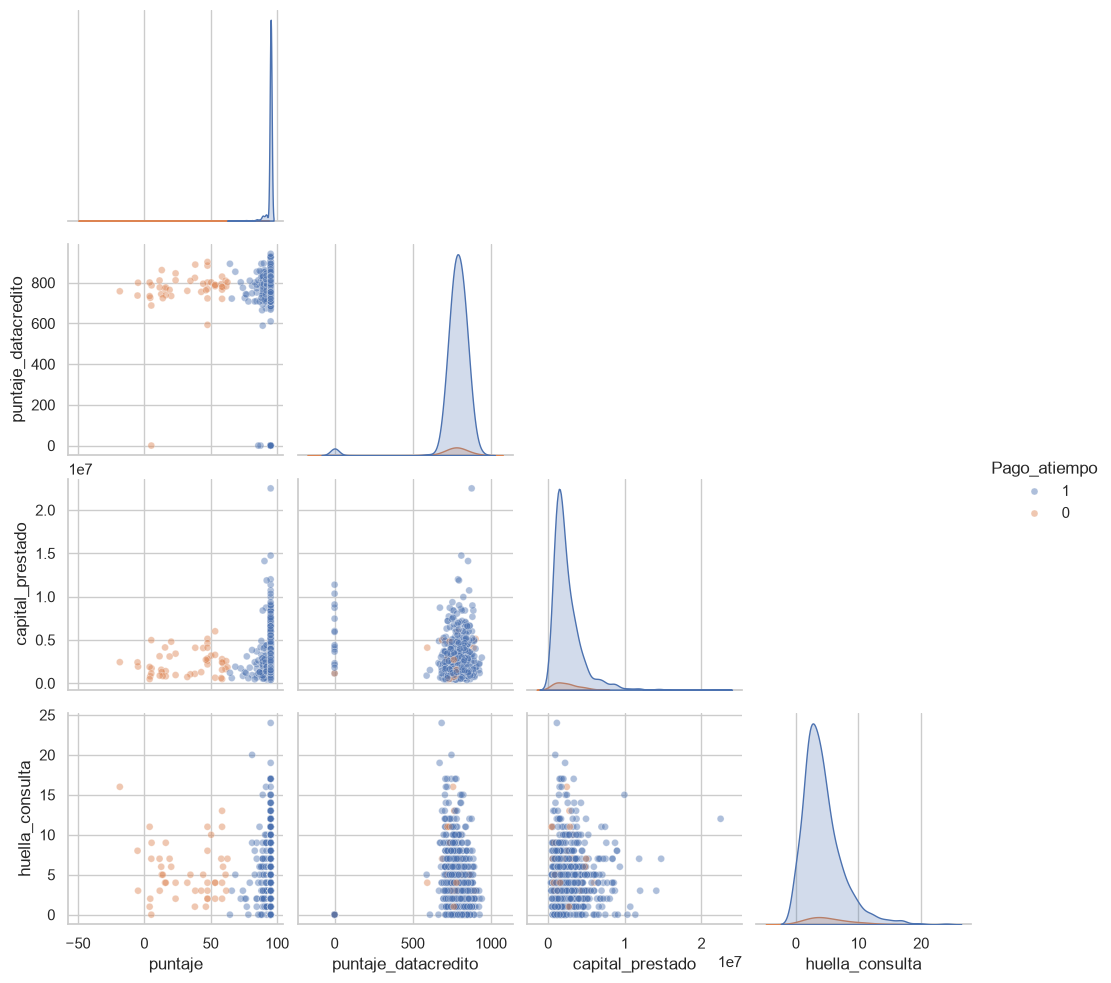

In [38]:
muestra_pairplot = (
    df[["puntaje", "puntaje_datacredito", "capital_prestado", "huella_consulta", "Pago_atiempo"]]
    .dropna()
    .sample(n=min(1000, len(df.dropna(subset=["puntaje", "puntaje_datacredito"]))), random_state=42)
)
muestra_pairplot["Pago_atiempo"] = muestra_pairplot["Pago_atiempo"].astype(str)

sns.pairplot(
    muestra_pairplot,
    vars=["puntaje", "puntaje_datacredito", "capital_prestado", "huella_consulta"],
    hue="Pago_atiempo",
    corner=True,
    plot_kws={"alpha": 0.45, "s": 25},
)
plt.show()

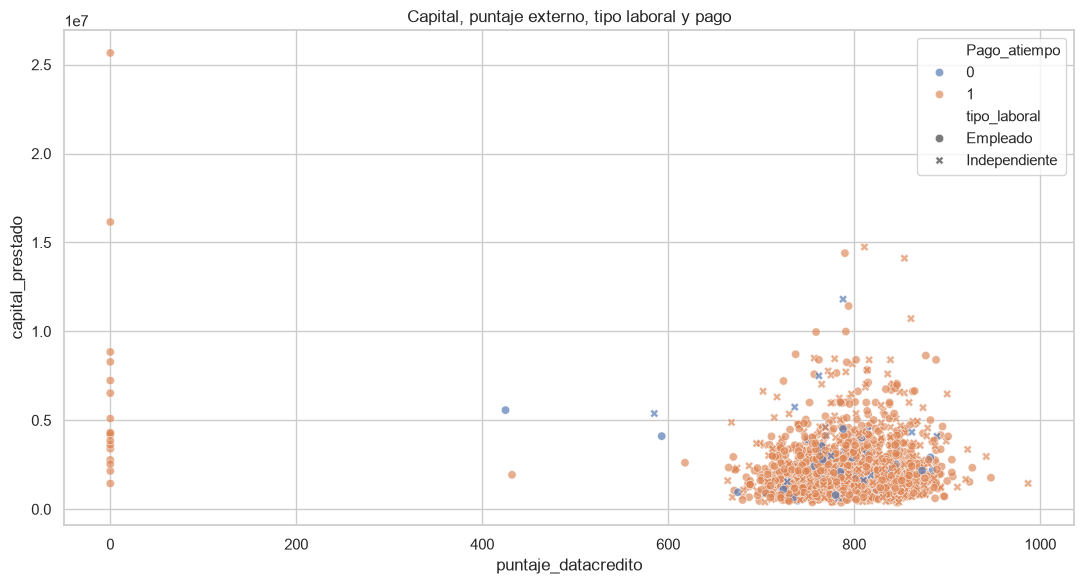

In [39]:
muestra_dispersion = df.sample(n=min(1500, len(df)), random_state=42)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=muestra_dispersion,
    x="puntaje_datacredito",
    y="capital_prestado",
    hue="Pago_atiempo",
    style="tipo_laboral",
    alpha=0.65,
)
plt.title("Capital, puntaje externo, tipo laboral y pago")
plt.tight_layout()
plt.show()

## 15. Tabla cruzada de variables categóricas

In [40]:
tabla_cruzada = pd.crosstab(
    df["tipo_laboral"],
    df["tendencia_ingresos"],
    values=df["Pago_atiempo"],
    aggfunc="mean",
    margins=True,
)
(tabla_cruzada * 100).round(2)

tendencia_ingresos,Decreciente,Estable,Creciente,All
tipo_laboral,,,,
Empleado,94.13,95.51,96.44,95.93
Independiente,92.66,95.20,95.18,94.80
All,93.73,95.37,96.09,95.59


Esta tabla estudia simultáneamente situación laboral, tendencia de ingresos y objetivo. Las diferencias son descriptivas; para afirmar que se generalizan deberían validarse con particiones de entrenamiento/prueba o inferencia estadística.

# Atributos adicionales y transformaciones candidatas

## 16. Creación exploratoria de atributos derivados

In [41]:
salario_valido = df["salario_cliente"].replace(0, pd.NA)

df["ratio_cuota_salario"] = df["cuota_pactada"] / salario_valido
df["ratio_otros_prestamos_salario"] = df["total_otros_prestamos"] / salario_valido
df["ratio_saldo_salario"] = df["saldo_total"] / salario_valido
df["total_creditos_sectores"] = (
    df["creditos_sectorFinanciero"]
    + df["creditos_sectorCooperativo"]
    + df["creditos_sectorReal"]
)
df["mes_prestamo"] = df["fecha_prestamo"].dt.month.astype("Int64")
df["trimestre_prestamo"] = df["fecha_prestamo"].dt.quarter.astype("Int64")

atributos_derivados = [
    "ratio_cuota_salario", "ratio_otros_prestamos_salario", "ratio_saldo_salario",
    "total_creditos_sectores", "mes_prestamo", "trimestre_prestamo",
]

df[atributos_derivados].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_cuota_salario,"10,739.00",0.09,1.24,0.00,0.04,0.06,0.10,125.80
ratio_otros_prestamos_salario,"10,739.00",0.69,24.08,0.00,0.21,0.33,0.47,"2,439.00"
ratio_saldo_salario,"10,584.00",0.02,0.58,0.00,0.00,0.01,0.01,59.58
total_creditos_sectores,"10,763.00",4.35,3.49,0.00,2.00,4.00,6.00,60.00
mes_prestamo,"10,763.00",5.27,3.72,1.00,2.00,4.00,8.00,12.00
trimestre_prestamo,"10,763.00",2.11,1.13,1.00,1.00,2.00,3.00,4.00


In [42]:
correlacion_derivados = (
    df[atributos_derivados + ["Pago_atiempo"]]
    .astype(float)
    .corr()["Pago_atiempo"]
    .drop("Pago_atiempo")
    .sort_values(key=abs, ascending=False)
)
correlacion_derivados.rename("correlacion_con_objetivo").to_frame()

,correlacion_con_objetivo
trimestre_prestamo,0.01
total_creditos_sectores,0.01
mes_prestamo,0.01
ratio_otros_prestamos_salario,0.00
ratio_saldo_salario,0.00
ratio_cuota_salario,0.00


Los ratios aproximan capacidad de pago y carga financiera. Se crean aquí para evaluar utilidad, pero en producción deben generarse dentro de un pipeline reproducible. Las divisiones por salario cero se convierten en nulo para evitar infinitos.

## 17. Transformaciones propuestas para el siguiente avance

In [43]:
transformaciones_propuestas = pd.DataFrame([
    ["Valores faltantes", "Imputación por mediana/moda o indicador de ausencia", "Evitar perder filas y preservar información", "Aprender solo con entrenamiento"],
    ["Variables monetarias", "log1p y/o RobustScaler", "Reducir asimetría e influencia de extremos", "Validar según el modelo"],
    ["Variables categóricas", "OneHotEncoder u ordinal según semántica", "Convertir categorías a representación modelable", "Manejar categorías desconocidas"],
    ["tendencia_ingresos", "Codificación ordinal", "Existe orden Decreciente < Estable < Creciente", "Conservar nulos como categoría o imputar"],
    ["tipo_credito", "Codificación nominal", "Los códigos no representan magnitud", "No usar el número como continuo"],
    ["Valores atípicos", "Validación, transformación o winsorización", "Reducir impacto sin borrar casos reales", "Requiere criterio de negocio"],
    ["Desbalance objetivo", "Pesos de clase o remuestreo dentro de CV", "Mejorar detección de la clase minoritaria", "Nunca remuestrear antes del split"],
    ["puntaje", "Auditar disponibilidad temporal", "Prevenir fuga de información", "Excluir si contiene información futura"],
], columns=["grupo", "transformacion_candidata", "motivo", "precaucion"])

transformaciones_propuestas

,grupo,transformacion_candidata,motivo,precaucion
0,Valores faltantes,Imputación por mediana/moda o indicador de ausencia,Evitar perder filas y preservar información,Aprender solo con entrenamiento
1,Variables monetarias,log1p y/o RobustScaler,Reducir asimetría e influencia de extremos,Validar según el modelo
2,Variables categóricas,OneHotEncoder u ordinal según semántica,Convertir categorías a representación modelable,Manejar categorías desconocidas
3,tendencia_ingresos,Codificación ordinal,Existe orden Decreciente < Estable < Creciente,Conservar nulos como categoría o imputar
4,tipo_credito,Codificación nominal,Los códigos no representan magnitud,No usar el número como continuo
5,Valores atípicos,"Validación, transformación o winsorización",Reducir impacto sin borrar casos reales,Requiere criterio de negocio
6,Desbalance objetivo,Pesos de clase o remuestreo dentro de CV,Mejorar detección de la clase minoritaria,Nunca remuestrear antes del split
7,puntaje,Auditar disponibilidad temporal,Prevenir fuga de información,Excluir si contiene información futura


# 18. Conclusiones finales

1. La base contiene **10.763 registros y 23 variables originales**, sin duplicados exactos.
2. `Pago_atiempo` está fuertemente desbalanceada: cerca de **95,25%** pertenece a la clase positiva. Accuracy no será suficiente para evaluar el modelo.
3. Los mayores faltantes están en `tendencia_ingresos` y `promedio_ingresos_datacredito`, alrededor del 27%.
4. Se detectaron **58 representaciones inválidas** en `tendencia_ingresos`; fueron unificadas como nulas solamente en la copia exploratoria.
5. Se detectaron **150 edades superiores a 100 años**, **24 salarios iguales a cero** y un valor negativo en `puntaje_datacredito`. Deben validarse con la fuente, no eliminarse automáticamente.
6. Las variables monetarias muestran asimetría y valores extremos; se evaluarán transformaciones logarítmicas o escalado robusto.
7. `puntaje` posee una relación extraordinariamente alta con el objetivo. Debe auditarse por posible `data leakage` antes de entrenar.
8. Se propusieron reglas de validación explícitas y atributos derivados relacionados con capacidad de pago, carga financiera y temporalidad.
9. Todas las transformaciones definitivas deberán implementarse dentro de un pipeline que aprenda exclusivamente con el conjunto de entrenamiento.

## Decisiones que requieren confirmación del negocio

- Límites válidos de edad y de puntajes.
- Significado de códigos infrecuentes en `tipo_credito`.
- Forma y momento de cálculo de `puntaje`.
- Tratamiento autorizado de valores extremos y faltantes.
- Disponibilidad real de cada variable al momento de predecir un crédito nuevo.

El EDA identifica asociaciones, anomalías e hipótesis; no demuestra causalidad.